<h1 align="center"> Tarea 2 - Detección automatizada de diabetes
<h2 align="center">  Integrantes: Bastián Araneda, Isaías Gómez, Junwei He y Nicolás Pacheco.
<h3 align="center"> IN4151-2 - Ingeniería de la Información 
<h3 align="center"> Otoño 2023

---

# Introducción

En el siguiente collab se analizará  un set de datos obtenido desde la Behavioral Risk Factor Surveillance System (BRFSS), correspondiente a una encuesta telefónica realizada anualmente por el Centers for Disease Control and Prevention en Estados Unidos. De la cual se buscará construir, a partir de esta y los métodos de Machine Learning, modelos que logren predecir si una persona padece o no diabetes. Esto se hará paso a paso empezando con la lectura de la base de datos que contiene variables binarias y discretas que caracterizan a la persona por su variable dependiente: Diabetes (1 si padece, 0 si no). Para esto se realizará un EDA, un Featuring Engeneering y finalmente un Machine Learning. Las distintas especificaciones y funcionalidades de las diferentes herramientas, algoritmos y modelos se irán explicando con mayor detalle a medida que vayan siendo utilizadas. 




# LECTURA DE BASE DE DATOS

Primero que todo, se debe importar las librerías a utilizar:

In [ ]:
# Importamos librerias a utilizar
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn import datasets
import matplotlib.pyplot as plt 

!python -m pip install ChernoffFace
from ChernoffFace import *

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


A continuación, se carga la base de datos:

In [ ]:
# CARGAR DATOS USANDO COLAB
df = pd.read_csv("https://raw.githubusercontent.com/JunTierSS/TICS/main/20230515221266AB52519B0DF330__diabetes.csv")
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0


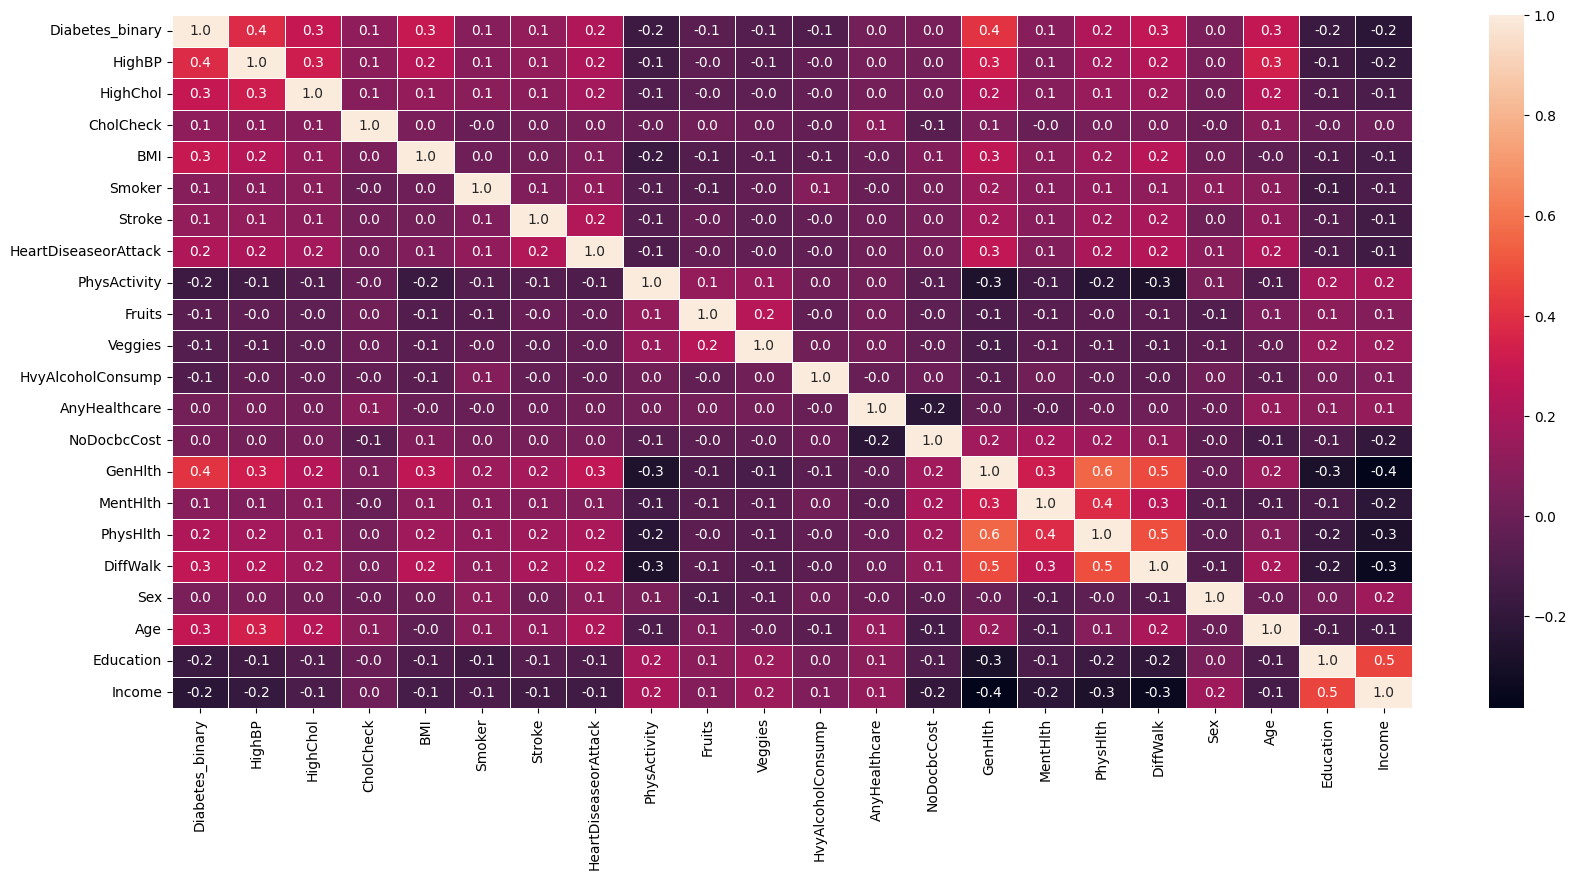

In [ ]:
#Esta función crea un mapa de calor de la correlación entre las columnas de datos en el DataFrame.
#Los colores y los valores numéricos indican la fuerza y la dirección de la correlación. Los valores oscuros o negativos indican una correlación negativa, mientras que los valores más claros o positivos indican una correlación positiva.
def plot_correlation_heatmap(X:pd.DataFrame):

    corrmat = X.corr()
    f, ax = plt.subplots(figsize=(20, 9))
    sns.heatmap(corrmat, annot=True, linewidths=.5, fmt= '.1f',ax=ax);

plot_correlation_heatmap(df)

Primero vamos a analizar el data frame limpiando data que contenga NA's. 

# FEATURE CLEANING




Featuring Engeneering es un marco metodológico que permite diseñar y generar conjuntos de información y discriminantes atributos o características para algoritmos de Machine Learning, a través de la ejecución de tareas que permitan la explotación de información y conocimiento pertenecientes a un dominio específico para definir, extraer y evaluar adecuadamente un conjunto de variables que brinden soporte de información confiable para la elaboración del modelo buscado.

In [ ]:
#Calcula y muestra la cantidad total de valores nulos en el DataFrame "df".
val_null_train=df.isnull()
print("Total de datos vacíos = ", val_null_train.sum().sum())

Total de datos vacíos =  1779


In [ ]:
#Definimos "total" como la suma de entradas vacías por cada variable de la base
total = df.isnull().sum().sort_values(ascending = False)

#Definimos "porcentaje" como el valor porcentual que 
#representa el total de entradas vacías de cada variable con respecto a la base
porcentaje = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
#Imprimimos los valores anteriores en una tabla para su visualización
missing_data = pd.concat([total, porcentaje], axis=1, keys=['Total', 'Porcentaje'])

missing_data 

,Total,Porcentaje
Smoker,371,0.005248
BMI,358,0.005064
PhysHlth,356,0.005036
Income,355,0.005022
Education,339,0.004795
AnyHealthcare,0,0.000000
Age,0,0.000000
Sex,0,0.000000
DiffWalk,0,0.000000
MentHlth,0,0.000000


In [ ]:
#Borrar filas con Na
df  = df.drop(df.loc[df['Smoker'].isnull()].index)
df  = df.drop(df.loc[df['BMI'].isnull()].index)
df  = df.drop(df.loc[df['PhysHlth'].isnull()].index)
df  = df.drop(df.loc[df['Income'].isnull()].index)
df  = df.drop(df.loc[df['Education'].isnull()].index)

df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0


In [ ]:
#Calcula y muestra la cantidad total de valores nulos en el DataFrame "df".
val_null_train=df.isnull()
print("Total de datos vacíos = ", val_null_train.sum().sum())

Total de datos vacíos =  0


# FEATURING GENERATION

Es el proceso de transformación de datos de entrada en un conjunto de características más significativas.

No se hace este proceso debido a que no es viable juntar variables binarias.


# FEATURING REDUCTION

Es el proceso de reducir la dimensionalidad de las variables manteniendo la información más relevante y significativa, algunas técnicas para esto es el análisis de componentes principales (PCA) o el análisis de discriminante lineal (LDA). (En este caso no se puede realizar este procedimiento debido a que es exclusivamente para variables continuas y para este caso son mayoritariamente binarias)

Las variables se agruparan en grandes grupos.


Factores de salud cardiovascular:
Presión arterial
Colesterol
Checkeo médico de colesterol
Índice de masa corporal
Fumador
Derrame cerebral
Presencia de enfermedades cardiacas  

Factores de estilo de vida saludable:
Si se ejercita físicamente
Si come frutas
Si come verduras
Consumo de alcohol

Acceso a la atención médica:
Cuenta con seguro de salud
Necesidad de ir al médico pero no poder pagar uno

Nivel socioeconómico:
Nivel de educación
Ingreso


Percepción y bienestar:
Percepción propia del nivel de salud
Días con estrés
Días con malestar físico
Dificultad para caminar

Factores demográficos:
Género
Edad

Enfermedades relacionadas con el corazón:
Presión arterial
Colesterol
Derrame cerebral
Presencia de enfermedades cardiacas

Hábitos de salud:
Si se ejercita físicamente
Si come frutas
Si come verduras
Consumo de alcohol

Donde finalmente se agrupa en 7 grandes grupos: HighBP, Veggies, NoDocbcCost, GenHlth, Sex, Age e Income (var independientes)



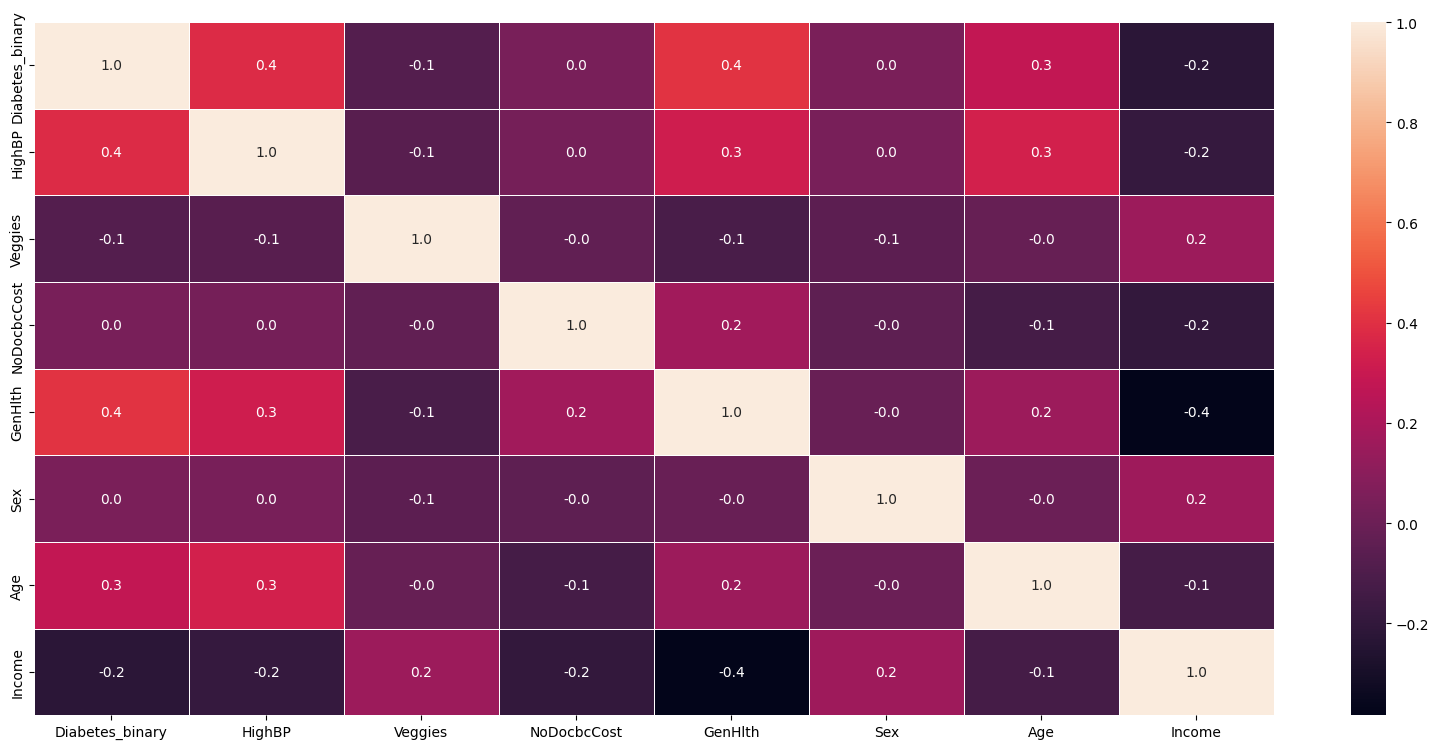

In [ ]:
#Reducción de la base a atributos escenciales
drop_list1 = ['HighChol','CholCheck','BMI','Smoker','Stroke','HeartDiseaseorAttack','Fruits','AnyHealthcare','Education','MentHlth','DiffWalk','PhysHlth','HvyAlcoholConsump','PhysActivity']
df = df.drop(drop_list1,axis = 1 )

plot_correlation_heatmap(df)

# EDA BÁSICO


 Un EDA (Exploratory Data Analysis) consiste en la exploración de datos interesantes entre las variables, ya sea medidas de tendencia central, correlaciones o histogramas que permiten la visualización de los datos en forma gráfica.


In [ ]:
#A continuación se muestra una tabla con todas las medidas importantes para cada variable:
df.describe()


,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
count,68925.000000,68925.000000,68925.000000,68925.000000,68925.000000,68925.000000,68925.000000,68925.000000
mean,0.499804,0.563743,0.788422,0.094044,2.837316,0.457164,8.581299,5.696090
std,0.500004,0.495924,0.408430,0.291892,1.113130,0.498165,2.854844,2.175952
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,7.000000,4.000000
50%,0.000000,1.000000,1.000000,0.000000,3.000000,0.000000,9.000000,6.000000
75%,1.000000,1.000000,1.000000,0.000000,4.000000,1.000000,11.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,13.000000,8.000000


In [ ]:
#Se explicita el promedio de cada variable
df.mean()

Diabetes_binary    0.499804
HighBP             0.563743
Veggies            0.788422
NoDocbcCost        0.094044
GenHlth            2.837316
Sex                0.457164
Age                8.581299
Income             5.696090
dtype: float64

In [ ]:
#Se explicita la mediana de cada variable
df.median()

Diabetes_binary    0.0
HighBP             1.0
Veggies            1.0
NoDocbcCost        0.0
GenHlth            3.0
Sex                0.0
Age                9.0
Income             6.0
dtype: float64

In [ ]:
#Se explicita la moda de cada variable
df.mode()

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
0,0.0,1.0,1.0,0.0,3.0,0.0,10.0,8.0


MEDIDAS DE DISPERSION

In [ ]:
#Se muestra el rango de cada variable
df_range = df.max() - df.min()
df_range

Diabetes_binary     1.0
HighBP              1.0
Veggies             1.0
NoDocbcCost         1.0
GenHlth             4.0
Sex                 1.0
Age                12.0
Income              7.0
dtype: float64

In [ ]:
#Luego. se muestran los cuartiles de cada variable
quartiles = df.quantile([0.25,0.5,0.75])
quartiles

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
0.25,0.0,0.0,1.0,0.0,2.0,0.0,7.0,4.0
0.50,0.0,1.0,1.0,0.0,3.0,0.0,9.0,6.0
0.75,1.0,1.0,1.0,0.0,4.0,1.0,11.0,8.0


In [ ]:
#Se muestra el Rango Intercuartilítico de cada variable
quartiles.loc["IQR"] = quartiles.loc[0.75] - quartiles.loc[0.25]
quartiles

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
0.25,0.0,0.0,1.0,0.0,2.0,0.0,7.0,4.0
0.5,0.0,1.0,1.0,0.0,3.0,0.0,9.0,6.0
0.75,1.0,1.0,1.0,0.0,4.0,1.0,11.0,8.0
IQR,1.0,1.0,0.0,0.0,2.0,1.0,4.0,4.0


In [ ]:
#Se muestra la varianza de cada variable
df.var()

Diabetes_binary    0.250004
HighBP             0.245940
Veggies            0.166815
NoDocbcCost        0.085201
GenHlth            1.239058
Sex                0.248169
Age                8.150132
Income             4.734766
dtype: float64

In [ ]:
#Se muestra la desviación estándar de cada variable
df.std()

Diabetes_binary    0.500004
HighBP             0.495924
Veggies            0.408430
NoDocbcCost        0.291892
GenHlth            1.113130
Sex                0.498165
Age                2.854844
Income             2.175952
dtype: float64

GRAFICOS DESCRIPTIVOS

<Axes: title={'center': 'Age'}, xlabel='Diabetes_binary'>

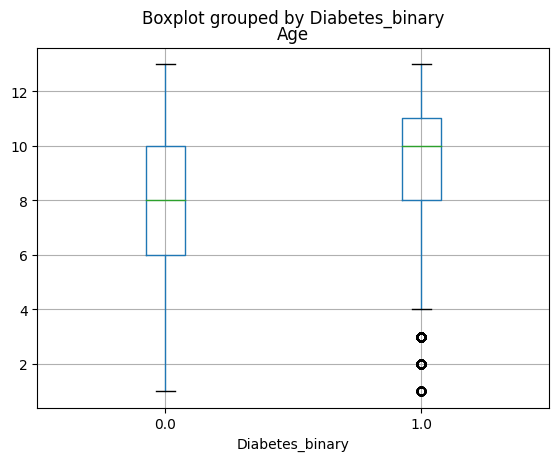

In [ ]:
#El siguiente gráfico muestra un diagrama de caja de la edad de las personas con y sin diabetes
df.boxplot(by="Diabetes_binary", column=["Age"], grid=True)

<Axes: title={'center': 'HighBP'}, xlabel='Diabetes_binary'>

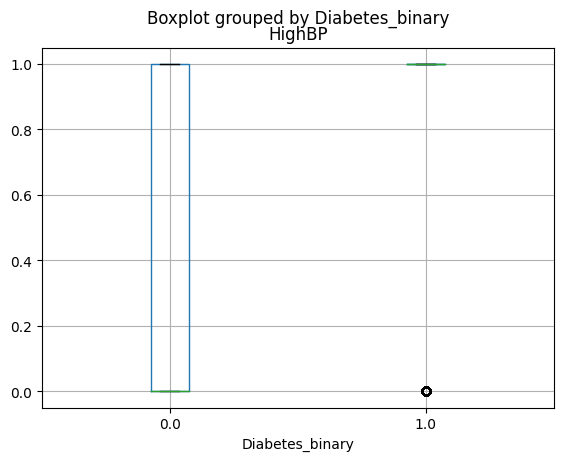

In [ ]:
#El siguiente gráfico muestra un diagrama de caja del nivel de colesterol de las personas con y sin diabetes
df.boxplot(by="Diabetes_binary", column=["HighBP"], grid=True)

<Axes: title={'center': 'GenHlth'}, xlabel='Diabetes_binary'>

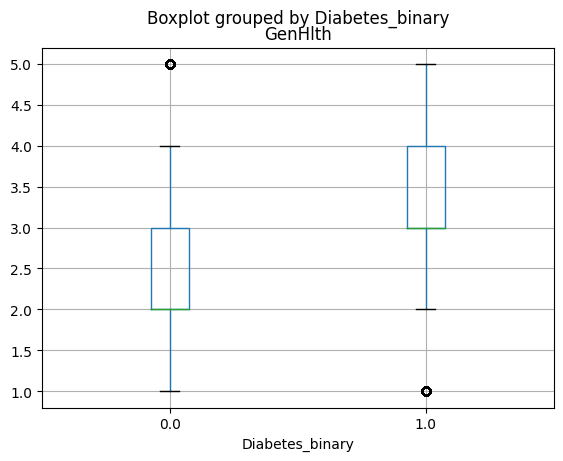

In [ ]:
#El siguiente gráfico muestra un diagrama de caja de la percepción de la salud de las personas con y sin diabetes
df.boxplot(by="Diabetes_binary", column=["GenHlth"], grid=True)

<Axes: xlabel='Diabetes_binary', ylabel='Age'>

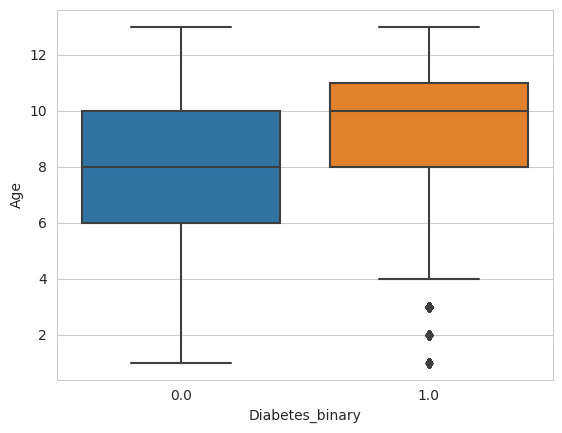

In [ ]:
sns.set_style("whitegrid")
sns.boxplot(x="Diabetes_binary", y="Age", data=df)

array([[<Axes: title={'center': 'Diabetes_binary'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'Veggies'}>],
       [<Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>,
        <Axes: title={'center': 'Sex'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>, <Axes: >]], dtype=object)

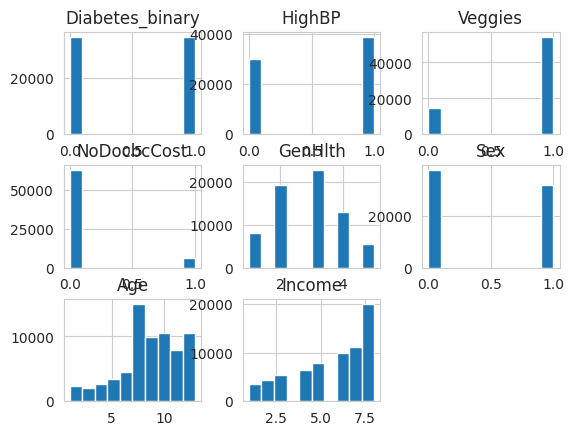

In [ ]:
#Se presentan histogramas de las distintas variables independientes según si las personas tienen o no diabetes
df.hist()

# EDA AVANZADO

In [ ]:
#Matriz de correlaciones según metodo de Pearson
df.corr(method="pearson")

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
Diabetes_binary,1.000000,0.382058,-0.079881,0.041183,0.408288,0.044686,0.278905,-0.225137
HighBP,0.382058,1.000000,-0.067471,0.027745,0.320260,0.041312,0.338610,-0.188679
Veggies,-0.079881,-0.067471,1.000000,-0.037064,-0.115538,-0.052282,-0.018639,0.154211
NoDocbcCost,0.041183,0.027745,-0.037064,1.000000,0.169932,-0.047328,-0.129590,-0.197527
GenHlth,0.408288,0.320260,-0.115538,0.169932,1.000000,-0.014700,0.155520,-0.383515
Sex,0.044686,0.041312,-0.052282,-0.047328,-0.014700,1.000000,-0.003864,0.159026
Age,0.278905,0.338610,-0.018639,-0.129590,0.155520,-0.003864,1.000000,-0.130003
Income,-0.225137,-0.188679,0.154211,-0.197527,-0.383515,0.159026,-0.130003,1.000000


In [ ]:
#Matriz de correlaciones según metodo de Spearman
df.corr(method='spearman')

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
Diabetes_binary,1.000000,0.382058,-0.079881,0.041183,0.414905,0.044686,0.261609,-0.233306
HighBP,0.382058,1.000000,-0.067471,0.027745,0.323762,0.041312,0.322633,-0.197792
Veggies,-0.079881,-0.067471,1.000000,-0.037064,-0.116903,-0.052282,-0.016954,0.155184
NoDocbcCost,0.041183,0.027745,-0.037064,1.000000,0.166486,-0.047328,-0.141112,-0.195114
GenHlth,0.414905,0.323762,-0.116903,0.166486,1.000000,-0.014278,0.138416,-0.382944
Sex,0.044686,0.041312,-0.052282,-0.047328,-0.014278,1.000000,-0.001025,0.157481
Age,0.261609,0.322633,-0.016954,-0.141112,0.138416,-0.001025,1.000000,-0.172541
Income,-0.233306,-0.197792,0.155184,-0.195114,-0.382944,0.157481,-0.172541,1.000000


In [ ]:
#Matriz de covarianzas
df.cov()

,Diabetes_binary,HighBP,Veggies,NoDocbcCost,GenHlth,Sex,Age,Income
Diabetes_binary,0.250004,0.094736,-0.016313,0.006011,0.227240,0.011131,0.398117,-0.244945
HighBP,0.094736,0.245940,-0.013666,0.004016,0.176793,0.010206,0.479399,-0.203605
Veggies,-0.016313,-0.013666,0.166815,-0.004419,-0.052528,-0.010638,-0.021733,0.137051
NoDocbcCost,0.006011,0.004016,-0.004419,0.085201,0.055213,-0.006882,-0.107988,-0.125458
GenHlth,0.227240,0.176793,-0.052528,0.055213,1.239058,-0.008151,0.494212,-0.928918
Sex,0.011131,0.010206,-0.010638,-0.006882,-0.008151,0.248169,-0.005495,0.172381
Age,0.398117,0.479399,-0.021733,-0.107988,0.494212,-0.005495,8.150132,-0.807578
Income,-0.244945,-0.203605,0.137051,-0.125458,-0.928918,0.172381,-0.807578,4.734766


In [ ]:
#Distancia euclidiana
one_array = df[df['Diabetes_binary'] == 1].drop(['Diabetes_binary'], axis=1).mean().to_numpy()
zero_array = df[df['Diabetes_binary'] == 0].drop(['Diabetes_binary'], axis=1).mean().to_numpy()


print('Distancia entre Diabetes1 y Diabetes0:', np.linalg.norm(one_array - zero_array))
#No se usará esto ya que no se puede hacer el PCA

Distancia entre Diabetes1 y Diabetes0: 2.1148119827223577


<Axes: >

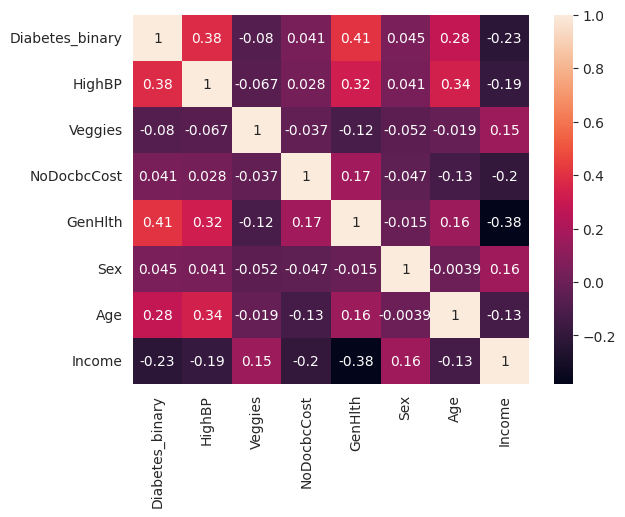

In [ ]:
# Heatmap de matriz de correlacion de pearson
corr_matrix = df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True)

<Axes: >

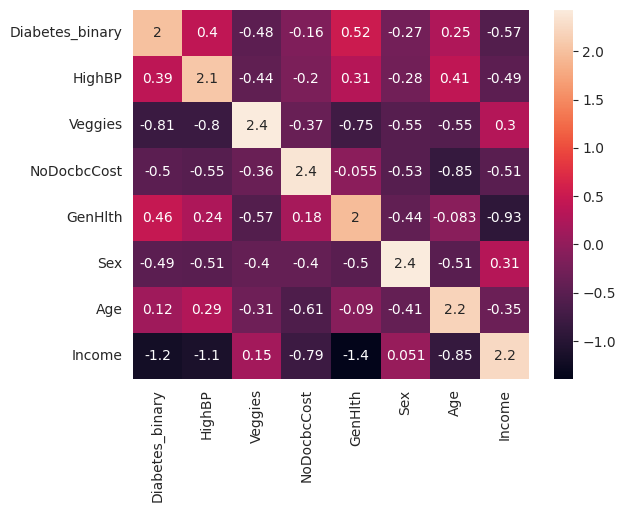

In [ ]:
#Heatmap de la matriz de correlaciones normalizada
corr_matrix_norm = (corr_matrix - corr_matrix.mean()) / corr_matrix.std()
sns.heatmap(corr_matrix_norm, annot=True)

<Axes: >

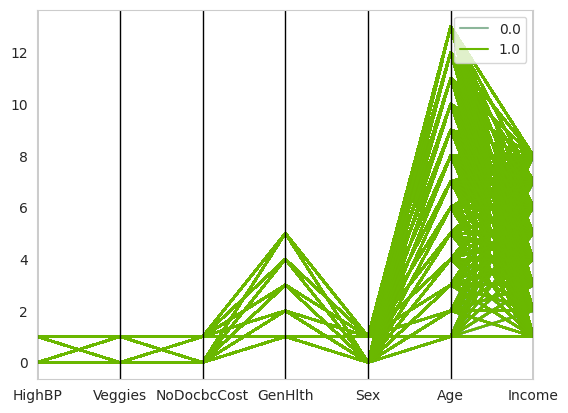

In [ ]:
# Coordenadas paralelas
pd.plotting.parallel_coordinates(df, 'Diabetes_binary')


In [ ]:
import plotly.express as px
import pandas as pd

# Features
features = df.columns.tolist()
one = list(df[df['Diabetes_binary'] == 1].drop(['Diabetes_binary'], axis=1).mean())
cero = list(df[df['Diabetes_binary'] == 0].drop(['Diabetes_binary'], axis=1).mean())


In [ ]:
one

[0.7532874684315946,
 0.7557839124502889,
 0.1060698423756858,
 3.291967836511945,
 0.479433365264594,
 9.3778338993875,
 5.206014688379924]

In [ ]:
#radar chart
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatterpolar(
  r=one,
  theta=features,
  fill='toself',
))

fig.update_layout(
  title='Diabetes Radar Chart',
  polar=dict(
    radialaxis=dict(
      visible=True
    ),
  ),
  showlegend=False
)

fig.show()

# CONCLUSIONES PRELIMINARES

Se puede observar que las correlaciones son relativamente bajas entre todas la variables ( en torno al (0.1) y que existen pocos NA en la base. Al reducir las variables según su índice de correlación, logramos simplificar nuestra base de datos sin pérdida de información relevante. Luego, en el EDA básico mediante el histograma se puede ver que la cantidad de personas con diabetes y sin diabetes son parecidas por lo que se pueden analizar estadísticamente los datos para el Machine Learning. Por otro lado mediante el EDA avanzado con la matriz de correlación de Pearson normalizada se puede ver que la gente más propensa a tener Diabetes son los que tienen una alta presión arterial y una mayor edad. En relación a la percepción de la salud, este está altamente correlacionado a la diabetes por lo que es probable que los síntomas de esta enfermedad puedan ser detectados por la misma persona. Por otro lado, la gente que consume vegetales y tiene mayor ingreso es menos propensa a tener diabetes, esto puede ser debido a que se pueden permitir comidas más saludables. Por último las mujeres son menos propensas a tener diabetes.

# Modelos de Clasificación

Machine learning corresponde al proceso que consiste en entrenar un modelo utilizando un conjunto de datos de entrenamiento, el cual consiste en ejemplos previamente etiquetados o datos históricos. El modelo utiliza estos datos para aprender patrones y reglas subyacentes, y luego puede aplicar ese conocimiento a nuevos datos no etiquetados para hacer predicciones o tomar decisiones.

## Definición de variables

In [ ]:
from sklearn.model_selection import train_test_split

# Definimos las variables independientes y la variable dependiente
X = df.drop(['Diabetes_binary'], axis=1).to_numpy()
y = df['Diabetes_binary'].to_numpy()

# Dividimos en sets de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

## Modelo 1:



 Bajo este modelo, lo que haremos será crear estructuras en forma de árbol que representan decisiones y sus posibles consecuencias. Cada nodo interno del árbol representa una característica, cada rama representa una decisión y cada hoja representa una clase o resultado. Gracias a este sistema podremos interpretar y analizar el comportamiento de los datos de una mejor forma.

In [ ]:
# Importamos los arboles de sklearn
from sklearn import tree

# Creamos el arbol de decision y lo entrenamos
dt_clf = tree.DecisionTreeClassifier()
dt_clf = dt_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
dt_pred = dt_clf.predict(X_test)

print('Predicciones:', dt_pred)
print('\nReales:', y_test)

Predicciones: [1. 1. 0. ... 0. 1. 0.]

Reales: [1. 1. 0. ... 0. 1. 0.]


## Modelo 2:

Este modelo se basa en el teorema de Bayes y asume la independencia condicional entre las características, es decir, el modelo calcula la probabilidad de que un punto de datos pertenezca a una clase en función de la probabilidad de las características observadas.


In [ ]:
# Importamos el modelo
from sklearn.naive_bayes import GaussianNB

# Creamos el modelo y lo entrenamos
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

# Clasificamos el set de testeo y visualizamos
gnb_pred = gnb_clf.predict(X_test)

print('Predicciones:', gnb_pred)
print('\nReales:', y_test)

Predicciones: [1. 1. 0. ... 0. 1. 0.]

Reales: [1. 1. 0. ... 0. 1. 0.]


## Evaluación de modelos

In [ ]:
# Importamos la funcion
from sklearn.metrics import confusion_matrix

# Matriz de confusion para el arbol de decision
dt_cm = confusion_matrix(y_test, dt_pred, labels=[0, 1])

print('Matriz de confusión para Decision Tree:\n', dt_cm)

# Matriz de confusion para Naive Bayes
gnb_cm = confusion_matrix(y_test, gnb_pred, labels=[0, 1])


print('\nMatriz de confusión para Naive Bayes:\n', gnb_cm)

Matriz de confusión para Decision Tree:
 [[4623 2264]
 [1809 5089]]

Matriz de confusión para Naive Bayes:
 [[4730 2157]
 [1771 5127]]


In [ ]:
# Importamos las librerias
from sklearn.metrics import classification_report

print('Métricas de performance para Decision Tree:\n', classification_report(y_test, dt_pred))

print('\nMétricas de performance para Naive Bayes:\n', classification_report(y_test, gnb_pred))

Métricas de performance para Decision Tree:
               precision    recall  f1-score   support

         0.0       0.72      0.67      0.69      6887
         1.0       0.69      0.74      0.71      6898

    accuracy                           0.70     13785
   macro avg       0.71      0.70      0.70     13785
weighted avg       0.71      0.70      0.70     13785


Métricas de performance para Naive Bayes:
               precision    recall  f1-score   support

         0.0       0.73      0.69      0.71      6887
         1.0       0.70      0.74      0.72      6898

    accuracy                           0.72     13785
   macro avg       0.72      0.72      0.71     13785
weighted avg       0.72      0.72      0.71     13785



F1-score: Es una medida combinada de precisión y recall que proporciona una visión general del equilibrio entre ambas métricas. Un F1-score alto indica un buen equilibrio entre precisión y recall.

Recall: Mide la proporción de casos positivos correctamente clasificados como positivos en relación con todos los casos positivos reales. Un alto recall indica que el modelo tiene una baja tasa de falsos negativos.

Precisión: Mide la proporción de casos positivos correctamente clasificados como positivos en relación con todos los casos clasificados como positivos. Una alta precisión indica que el modelo tiene una baja tasa de falsos positivos.

In [ ]:
# Tambien podemos calcular metricas individuales
from sklearn.metrics import accuracy_score

print('Accuracy para Decision Tree:', accuracy_score(y_test, dt_pred))
print('Accuracy para Naive Bayes:', accuracy_score(y_test, gnb_pred))

Accuracy para Decision Tree: 0.7045339136742836
Accuracy para Naive Bayes: 0.7150525933986217


In [ ]:
# Transformamos nuestra datos para solo dos clases para poder mostrar la curva ROC
df2 = df
df2= df2[(df2['Diabetes_binary'] == 1) | (df2['Diabetes_binary'] == 0)]

df2.loc[df2['Diabetes_binary'] == 1, 'Diabetes_binary'] = 1
df2.loc[df2['Diabetes_binary'] == 0, 'Diabetes_binary'] = 0
df2['Diabetes_binary'] = df2['Diabetes_binary'].astype(float)

In [ ]:
df2.dtypes

Diabetes_binary    float64
HighBP             float64
Veggies            float64
NoDocbcCost        float64
GenHlth            float64
Sex                float64
Age                float64
Income             float64
dtype: object

Curvas ROC: Representan la tasa de verdaderos positivos frente a la tasa de falsos positivos a medida que se varía el umbral de clasificación. Una curva ROC que se acerca al área bajo la curva (AUC) de 1 indica un mejor rendimiento del modelo.

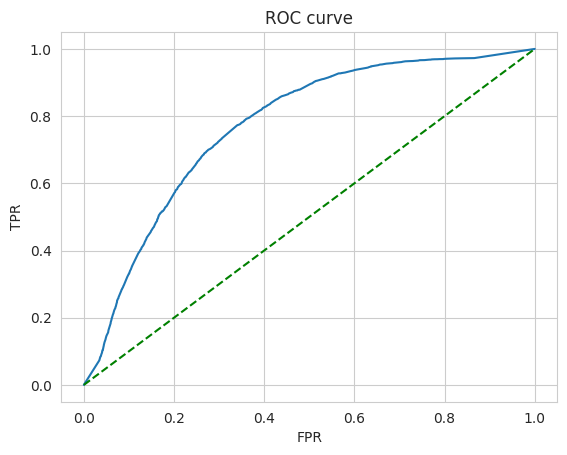


AUC Score para Árbol de Decisión: 0.7705583150818127


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Definimos las variables independientes y la variable dependiente
X_2 = df2.drop(['Diabetes_binary'], axis=1).to_numpy()
y_2 = df2['Diabetes_binary'].to_numpy()

# Dividimos en sets de entrenamiento y testeo
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=45)

# Entrenamos el modelo y predecimos
dt_roc = tree.DecisionTreeClassifier()
dt_roc.fit(X_train_2, y_train_2)
dt_roc_score = dt_roc.predict_proba(X_test_2)[:,1]


# Calculamos la curva ROC
fpr, tpr, _ = roc_curve(y_test_2, dt_roc_score)

# Visualizamos
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve Arbol')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.show()
print('\nAUC Score para Árbol de Decisión:', roc_auc_score(y_test_2, dt_roc_score))

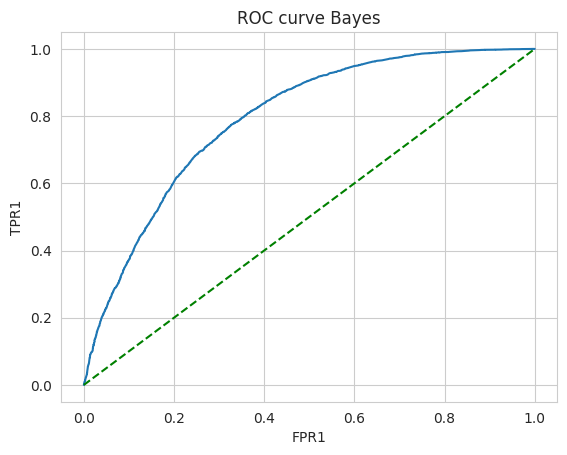


AUC Score para Naives Bayes: 0.7926633012917126


In [ ]:
# Entrenamos el modelo y predecimos
dt_roc = GaussianNB()
dt_roc.fit(X_train_2, y_train_2)
dt_roc_score = dt_roc.predict_proba(X_test_2)[:,1]


# Calculamos la curva ROC
fpr1, tpr1, _ = roc_curve(y_test_2, dt_roc_score)

# Visualizamos
plt.plot(fpr1, tpr1)
plt.xlabel('FPR1')
plt.ylabel('TPR1')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')

plt.title('ROC curve Bayes')
plt.show()
print('\nAUC Score para Naives Bayes:', roc_auc_score(y_test_2, dt_roc_score))

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

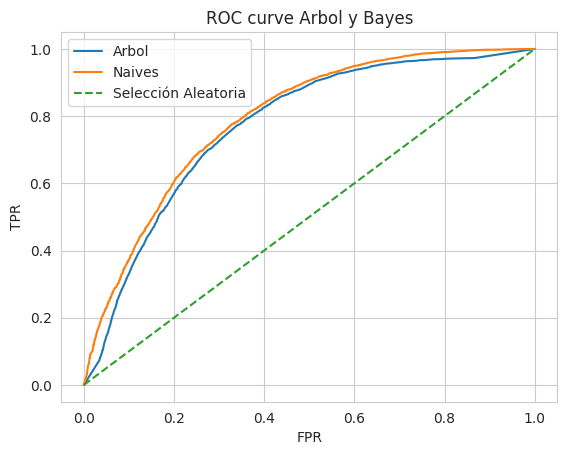

In [ ]:
#A CONTINUACION, PLOTEAMOS LOS DOS GRÁFICOS ANTERIORES PARA REALIZAR UNA MEJOR COMPARACION ENTRE AMBOS MODELOS

fig, ax = plt.subplots()
x = np.linspace(0, 1, 100)
y = x
# Plotear el primer gráfico
ax.plot(fpr, tpr, label='Arbol')

# Plotear el segundo gráfico
ax.plot(fpr1, tpr1, label='Naives')
ax.plot(x, y,linestyle = "--", label='Selección Aleatoria')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve Arbol y Bayes')

# Agregar una leyenda
ax.legend()

# Mostrar el gráfico
plt


# Conclusiones

Evaluación del rendimiento:
Se evaluó el rendimiento de los modelos utilizando métricas de evaluación comunes, como precisión, recall, F1-score y curvas ROC. Estas métricas proporcionan una medida cuantitativa del rendimiento de los modelos en la detección de pacientes en riesgo de diabetes.

Resultados del modelo de Naive Bayes: Se observó que el modelo de Naive Bayes mostró una precisión alta y un recall razonablemente bueno en la detección de pacientes en riesgo de diabetes. Esto indica que el modelo logró identificar correctamente a una gran proporción de los casos positivos, minimizando así los falsos negativos.

La precisión del modelo de Árboles de Decisión para personas sin diabetes es de 0.72 y para personas con diabetes de 0.69, en cambio la precisión del modelo Naive Bayes es de 0.73 para personas sin diabetes y de 0.7 para personas sin diabetes. Respecto a la precisión general del modelo el de Árboles es de 0.704 y el de Bayes es de 0.715, con lo cual se obtienen resultados más certeros en el modelo Naive Bayes

Resultados del modelo de árboles de decisión: Se encontró que el modelo de árboles de decisión obtuvo una precisión similar al modelo de Naive Bayes, pero su recall fue ligeramente inferior. Esto significa que el modelo de árboles de decisión tuvo una tendencia ligeramente mayor a clasificar erróneamente algunos casos positivos como negativos.

Conclusión:
Basándonos en los resultados de la evaluación, se puede concluir que el modelo de Naive Bayes superó ligeramente al modelo de árboles de decisión en la detección de pacientes en riesgo de diabetes. El modelo de Naive Bayes mostró una mejor capacidad para identificar correctamente a los casos positivos, lo que es crucial en la detección temprana de la enfermedad. Sin embargo, es importante tener en cuenta que la elección del modelo puede depender del contexto específico y de las preferencias del usuario.

Además, es fundamental mencionar que estos resultados se basan en el análisis de datos y la construcción de modelos utilizando el conjunto de datos específico disponible. Para obtener conclusiones más sólidas y generalizables, se recomienda realizar pruebas adicionales con conjuntos de datos más amplios y diversas técnicas de validación cruzada.

